# 📊 Final Project Delivery: Data Warehouse & Real-time Kafka Pipeline
**Course:** ETL (G51)  
**Program:** Data Engineering and Artificial Intelligence  

This notebook contains the complete monolithic implementation of the data warehouse and real-time streaming pipeline.

### Architecture Overview
1. **Data Extraction (Sources):** Extracts data from a local dataset (WHO Household Air Pollution CSV) and two APIs (OpenAQ API and REST Countries API).
2. **Orchestration (Airflow DAG):** Automates the extract, transform, validate, and load tasks.
3. **Data Quality (Great Expectations):** Validates staging data schema and values before ingestion into the data warehouse.
4. **Data Modeling (DuckDB/SQLite Star Schema):** Builds a relational dimensional model containing `dim_location`, `dim_date`, and `fact_air_quality`.
5. **Streaming (Kafka KRaft Broker):** Streams facts from the warehouse to a Kafka topic in real time.
6. **Analytics (Analytical Dashboard):** Connects to the SQLite warehouse to build Plotly dashboards.
7. **Real-time Consumption (Kafka Consumer & Operational Dashboard):** Consumes Kafka messages in real time and renders a live, updating dashboard in Colab.


## collab env

In [1]:
!PYTHON_VERSION="$(python -c 'import sys; print(f"{sys.version_info.major}.{sys.version_info.minor}")')" && \
pip install \
  "numpy==1.26.4" \
  "apache-airflow==2.11.2" \
  "great-expectations>=1.0.0" \
  "confluent-kafka" \
  "plotly" \
  "scikit-learn" \
  "matplotlib" \
  "seaborn" \
  --constraint "https://raw.githubusercontent.com/apache/airflow/constraints-2.11.2/constraints-${PYTHON_VERSION}.txt"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.0/100.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━

In [1]:
# runMe (COLLAB ONLY)
from google.colab import drive
from google.colab import userdata
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive')

# Source and destination paths
src = "/content/drive/My Drive/2026/etl/datasets/who-household-air-pollution.csv"
dst = '/content/data/raw/who-household-air-pollution.csv'

# Make sure destination folder exists
os.makedirs(os.path.dirname(dst), exist_ok=True)

# Copy the file
shutil.copy(src, dst)

print(f"Copied to: {dst}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied to: /content/data/raw/who-household-air-pollution.csv


In [2]:
import os

# 1. Instalar Airflow y la última versión de Great Expectations
print("Instalando dependencias (puede tardar 1 minuto)...")
#!PYTHON_VERSION="$(python -c 'import sys; print(f"{sys.version_info.major}.{sys.version_info.minor}")')" && \
#pip install "apache-airflow==2.11.2" "great-expectations>=1.0.0" pandas --constraint "https://raw.githubusercontent.com/apache/airflow/constraints-2.11.2/constraints-${PYTHON_VERSION}.txt" > /dev/null 2>&1
!PYTHON_VERSION="$(python -c 'import sys; print(f"{sys.version_info.major}.{sys.version_info.minor}")')" && \
pip install "apache-airflow==2.11.2" "great-expectations>=1.0.0" --constraint "https://raw.githubusercontent.com/apache/airflow/constraints-2.11.2/constraints-${PYTHON_VERSION}.txt" > /dev/null 2>&1
# deleted pandas

# 2. Configuración de entorno
os.environ['AIRFLOW_HOME'] = '/content/airflow'
os.environ['AIRFLOW__CORE__LOAD_EXAMPLES'] = 'False'
os.environ['AIRFLOW__WEBSERVER__WEB_SERVER_PORT'] = '8081'

# 3. Inicializar Airflow
!airflow db migrate > /dev/null 2>&1
!mkdir -p /content/airflow/dags

print("✅ Entorno de Airflow y Great Expectations listo.")

Instalando dependencias (puede tardar 1 minuto)...
✅ Entorno de Airflow y Great Expectations listo.


## 2. Setting up Apache Kafka (KRaft mode)
We configure a standalone Kafka broker inside Colab without needing ZooKeeper (using Kafka Raft metadata mode).


In [3]:
#!pip install -q confluent-kafka plotly pandas scikit-learn matplotlib seaborn
!pip install -q confluent-kafka plotly pandas scikit-learn matplotlib seaborn

import time
import os

# 1. Download and extract Kafka
!wget -q https://archive.apache.org/dist/kafka/3.7.0/kafka_2.13-3.7.0.tgz
!tar -xzf kafka_2.13-3.7.0.tgz

# 2. Configure KRaft
!uuid=$(./kafka_2.13-3.7.0/bin/kafka-storage.sh random-uuid) && ./kafka_2.13-3.7.0/bin/kafka-storage.sh format -t $uuid -c ./kafka_2.13-3.7.0/config/kraft/server.properties

# 3. Start Kafka in the background
!./kafka_2.13-3.7.0/bin/kafka-server-start.sh -daemon ./kafka_2.13-3.7.0/config/kraft/server.properties

print("Starting Local Kafka Broker...")
time.sleep(10) # Give it time to fully start
print("Kafka is ready!")

^C

gzip: stdin: unexpected end of file
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now
metaPropertiesEnsemble=MetaPropertiesEnsemble(metadataLogDir=Optional.empty, dirs={/tmp/kraft-combined-logs: EMPTY})
Formatting /tmp/kraft-combined-logs with metadata.version 3.7-IV4.
Starting Local Kafka Broker...
Kafka is ready!


## 3. Airflow DAG Definition
We create and save our Airflow DAG, which will extract data from the sources, clean/merge it, run data quality audits using Great Expectations, load it into the Star Schema tables, and publish real-time updates to the Kafka Broker.


In [11]:
%%writefile /content/airflow/dags/etl_air_quality.py
from datetime import datetime, timedelta
from airflow import DAG
from airflow.operators.python import PythonOperator, BranchPythonOperator
from airflow.operators.bash import BashOperator
from airflow.operators.empty import EmptyOperator

from confluent_kafka import Producer

import sqlite3
import pandas as pd
import requests
import json
import time

default_args = {
    'owner': 'data_engineer',
    'depends_on_past': False,
    'retries': 0,
}

with DAG(
    'final_air_quality_warehouse_pipeline',
    default_args=default_args,
    schedule_interval=timedelta(minutes=5),
    start_date=datetime(2025, 1, 1),
    catchup=False,
) as dag:

    def extract_and_transform():
        print("Ingesting WHO Air Pollution CSV...")
        df_who = pd.DataFrame()
        try:
            raw_csv_path = '/content/data/raw/who-household-air-pollution.csv'
            df_who = pd.read_csv(raw_csv_path)
            # Filter specifically for Clean Fuels indicator
            df_who = df_who[df_who['IndicatorCode'] == 'PHE_HHAIR_PROP_POP_CLEAN_FUELS'].copy()
            df_who.rename(columns={'SpatialDimValueCode': 'iso_alpha3', 'FactValueNumeric': 'clean_fuel_access'}, inplace=True)
            df_who = df_who[['iso_alpha3', 'clean_fuel_access', 'Period']].dropna()
            df_who = df_who.sort_values('Period').groupby('iso_alpha3').tail(1)
        except Exception as e:
            print(f"CSV Ingestion issue: {e}")

        print("Querying OpenAQ API...")
        df_aq = pd.DataFrame()
        openaq_url = "https://api.openaq.org/v3/parameters/2/latest?limit=1000"

        # Check for Colab API Key secrets
        api_key = None
        try:
            from google.colab import userdata
            api_key = userdata.get('openaq_api_key')
        except Exception:
            pass

        headers = {"X-API-Key": api_key} if api_key else {}

        try:
            response_aq = requests.get(openaq_url, headers=headers, timeout=10)
            if response_aq.status_code == 200:
                aq_data = response_aq.json().get('results', [])
                aq_list = []
                for item in aq_data:
                    iso = item.get('country', {}).get('iso')
                    val = item.get('value')
                    if iso and val is not None:
                        aq_list.append({'country_iso': iso.upper(), 'pm25_value': val})
                if aq_list:
                    df_aq = pd.DataFrame(aq_list).groupby('country_iso', as_index=False)['pm25_value'].mean()
                    print(f"Successfully fetched {len(df_aq)} records from OpenAQ API.")
        except Exception as e:
            print(f"OpenAQ API query failed: {e}")

        # If OpenAQ fails, apply academic robust mock fallback
        if df_aq.empty:
            print("Applying fallback simulated OpenAQ readings for Latin American countries...")
            import random
            mock_data = [
                {'country_iso': 'EC', 'pm25_value': random.uniform(8.0, 18.0)},
                {'country_iso': 'PE', 'pm25_value': random.uniform(25.0, 45.0)},
                {'country_iso': 'BR', 'pm25_value': random.uniform(12.0, 22.0)},
                {'country_iso': 'AR', 'pm25_value': random.uniform(9.0, 19.0)},
                {'country_iso': 'MX', 'pm25_value': random.uniform(18.0, 32.0)},
                {'country_iso': 'CO', 'pm25_value': random.uniform(10.0, 20.0)},
                {'country_iso': 'CL', 'pm25_value': random.uniform(15.0, 35.0)}
            ]
            df_aq = pd.DataFrame(mock_data)

        print("Querying REST Countries API...")
        df_countries = pd.DataFrame()
        countries_url = "https://restcountries.com/v3.1/all?fields=cca3,cca2,name,region,population"
        try:
            response_countries = requests.get(countries_url, timeout=10)
            if response_countries.status_code == 200:
                c_data = response_countries.json()
                df_countries = pd.DataFrame([{
                    'iso_alpha3': c.get('cca3'),
                    'iso_alpha2': c.get('cca2'),
                    'country_name': c.get('name', {}).get('common'),
                    'region': c.get('region'),
                    'population': c.get('population', 0)
                } for c in c_data])
        except Exception as e:
            print(f"REST Countries request failed: {e}")

        print("Merging and cleansing data for staging...")
        if not df_countries.empty:
            if not df_who.empty:
                df_merged = pd.merge(df_countries, df_who, on='iso_alpha3', how='left')
            else:
                df_merged = df_countries.copy()
                df_merged['clean_fuel_access'] = 50.0

            if not df_aq.empty:
                df_merged = pd.merge(df_merged, df_aq, left_on='iso_alpha2', right_on='country_iso', how='left')
            else:
                df_merged['pm25_value'] = 12.0

            df_merged['pm25_value'] = df_merged['pm25_value'].fillna(12.0)
            df_merged['clean_fuel_access'] = df_merged['clean_fuel_access'].fillna(50.0)

            df_merged.to_csv('/content/staging_air_quality.csv', index=False)
            print(f"Staging file saved. {len(df_merged)} rows.")

    extract_transform_task = PythonOperator(
        task_id='extract_and_transform',
        python_callable=extract_and_transform,
    )

    def validate_data_quality():
        import great_expectations as gx
        import great_expectations.expectations as gxe

        try:
            print("Loading staging data for Great Expectations validation...")
            df = pd.read_csv('/content/staging_air_quality.csv')
            context = gx.get_context()

            # Config Expectation Suite
            try:
                suite = gx.ExpectationSuite(name="air_quality_contract")
                suite.add_expectation(gxe.ExpectColumnValuesToNotBeNull(column="iso_alpha3"))
                suite.add_expectation(gxe.ExpectColumnValuesToBeBetween(column="population", min_value=0))
                suite.add_expectation(gxe.ExpectColumnValuesToBeBetween(column="pm25_value", min_value=0))
                context.suites.add(suite)
            except Exception:
                suite = context.suites.get(name="air_quality_contract")

            # Setup Data Source
            try:
                source = context.data_sources.add_pandas("airflow_ds")
            except Exception:
                source = context.data_sources.get("airflow_ds")

            try:
                asset = source.add_dataframe_asset("air_asset")
            except Exception:
                asset = source.get_asset("air_asset")

            try:
                batch_def = asset.add_batch_definition_whole_dataframe("daily_batch")
            except Exception:
                batch_def = asset.get_batch_definition("daily_batch")

            # Setup Validation
            try:
                validation = gx.ValidationDefinition(data=batch_def, suite=suite, name="air_audit")
                context.validation_definitions.add(validation)
            except Exception:
                validation = context.validation_definitions.get("air_audit")

            # Setup Checkpoint
            try:
                ckpt = gx.Checkpoint(name="air_checkpoint", validation_definitions=[validation])
                context.checkpoints.add(ckpt)
            except Exception:
                ckpt = context.checkpoints.get("air_checkpoint")

            # Run Audit
            results = ckpt.run(batch_parameters={"dataframe": df})

            if results.success:
                print("✅ Data Quality contract passed successfully!")
                return 'load_data_warehouse'
            else:
                print("❌ Data Quality contract validation FAILED.")
                return 'ruta_mover_a_cuarentena'

        except Exception as e:
            print(f"Exception during validation: {e}")
            return 'ruta_mover_a_cuarentena'

    validate_task = BranchPythonOperator(
        task_id='validate_with_gx',
        python_callable=validate_data_quality,
    )

    def load_sqlite_dw():
        print("Connecting to SQLite Warehouse database...")
        conn = sqlite3.connect('/content/air_quality_warehouse.db')
        cursor = conn.cursor()

        cursor.execute('DROP TABLE IF EXISTS dim_location')
        cursor.execute('CREATE TABLE dim_location (iso_alpha3 TEXT PRIMARY KEY, country_name TEXT, region TEXT, population INTEGER)')

        cursor.execute('DROP TABLE IF EXISTS fact_air_quality')
        cursor.execute('CREATE TABLE fact_air_quality (iso_alpha3 TEXT, pm25_value REAL, clean_fuel_access REAL, timestamp DATETIME DEFAULT CURRENT_TIMESTAMP)')

        df = pd.read_csv('/content/staging_air_quality.csv')

        # Load dim_location
        dim_loc = df[['iso_alpha3', 'country_name', 'region', 'population']].drop_duplicates()
        dim_loc.to_sql('dim_location', conn, if_exists='append', index=False)

        # Load fact table
        fact_aq = df[['iso_alpha3', 'pm25_value', 'clean_fuel_access']]
        fact_aq.to_sql('fact_air_quality', conn, if_exists='append', index=False)

        conn.commit()
        conn.close()
        print("✅ Data loaded successfully into Dimensional model tables.")

    load_dw_task = PythonOperator(
        task_id='load_data_warehouse',
        python_callable=load_sqlite_dw,
    )

    def stream_metrics_to_kafka():
        from confluent_kafka import Producer

        print("Querying SQLite fact table to stream events...")
        conn = sqlite3.connect('/content/air_quality_warehouse.db')
        query = """
            SELECT f.iso_alpha3, l.country_name, f.pm25_value, f.clean_fuel_access, f.timestamp
            FROM fact_air_quality f
            JOIN dim_location l ON f.iso_alpha3 = l.iso_alpha3
        """
        df_facts = pd.read_sql_query(query, conn)
        conn.close()

        # Connect to local Kafka Broker
        try:
            #producer = Producer(
            #    bootstrap_servers=['localhost:9092'],
            #    value_serializer=lambda v: json.dumps(v).encode('utf-8')
            #)
            producer = Producer({
                'bootstrap.servers': 'localhost:9092'
            })

            topic = 'air_quality_metrics'
            print(f"Streaming {len(df_facts)} records to topic '{topic}'...")

            # Stream with a slight delay
            for _, row in df_facts.iterrows():
                payload = {
                    'iso_alpha3': row['iso_alpha3'],
                    'country_name': row['country_name'],
                    'pm25_value': float(row['pm25_value']),
                    'clean_fuel_access': float(row['clean_fuel_access']),
                    'timestamp': str(row['timestamp'])
                }
                #producer.send(topic, value=payload)
                producer.produce(
                    topic,
                    value=json.dumps(payload).encode('utf-8')
                )
                time.sleep(0.05) # delay to simulate real-time
            producer.flush()
            print("✅ All events streamed successfully to Kafka broker.")
        except Exception as e:
            print(f"Failed to stream to Kafka: {e}")

    stream_kafka_task = PythonOperator(
        task_id='stream_to_kafka',
        python_callable=stream_metrics_to_kafka,
    )

    mover_cuarentena = BashOperator(
        task_id='ruta_mover_a_cuarentena',
        bash_command='echo "[ ❌ ] Data issues found. Moving staging data to quarantine directory..." && mv /content/staging_air_quality.csv /content/data/quarantine/quarantine_out.csv',
    )

    enviar_alerta = BashOperator(
        task_id='enviar_alerta',
        bash_command='echo "⚠️ PIPELINE NOTIFICATION: Staged air quality batch failed validation rules."',
    )

    fin = EmptyOperator(task_id='fin_proceso', trigger_rule='none_failed_min_one_success')

    # DAG Dependency graph
    extract_transform_task >> validate_task
    validate_task >> load_dw_task >> stream_kafka_task >> fin
    validate_task >> mover_cuarentena >> enviar_alerta >> fin


Overwriting /content/airflow/dags/etl_air_quality.py


## 4. Launching Airflow Standalone Server & Secure Tunnel
We set up an admin user, start the Airflow webserver in standalone mode, and create a Cloudflare tunnel to access the Airflow UI externally.


In [12]:
import os, time, urllib.request, re

os.system("fuser -k 8081/tcp > /dev/null 2>&1")
os.system("pkill -9 -f cloudflared > /dev/null 2>&1")

print("1/3 Configuring Admin User...")
os.system("airflow users create -u admin -p admin -f Data -l Engineer -r Admin -e admin@example.com > /dev/null 2>&1")

print("2/3 Starting Airflow Orchestrator (~30 seconds)...")
get_ipython().system_raw('airflow standalone > /content/airflow.log 2>&1 &')

ready = False
for _ in range(30):
    try:
        if urllib.request.urlopen('http://localhost:8081').getcode() == 200:
            ready = True
            break
    except:
        time.sleep(2)

if not ready:
    print("❌ Error starting server. Check logs.")
else:
    print("✅ Webserver active.\n3/3 Initializing Tunnel...")
    os.system("wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared")
    os.system("chmod +x /content/cloudflared")
    get_ipython().system_raw('/content/cloudflared tunnel --url http://localhost:8081 > /content/tunnel.log 2>&1 &')
    time.sleep(6)

    tunnel_logs = open('/content/tunnel.log', 'r').read()
    urls = re.findall(r'https://[a-zA-Z0-9-]+\.trycloudflare\.com', tunnel_logs)

    if urls:
        print("\n" + "═"*55)
        print("🚀 AIRFLOW URL: " + urls[0])
        print("👤 User: admin  |  🔑 Pass: admin")
        print("═"*55)
    else:
        print("❌ Tunnel generation failed.")


1/3 Configuring Admin User...
2/3 Starting Airflow Orchestrator (~30 seconds)...
✅ Webserver active.
3/3 Initializing Tunnel...

═══════════════════════════════════════════════════════
🚀 AIRFLOW URL: https://identifies-ecological-contributors-civilian.trycloudflare.com
👤 User: admin  |  🔑 Pass: admin
═══════════════════════════════════════════════════════


## 5. Analytical Dashboard (Static Analytical Process)
Here, we query the SQL-compliant Star Schema warehouse directly and use Plotly to render business intelligence reports.
*(Note: Please ensure the DAG has run at least once in Airflow UI before executing this cell to populate the database).*


In [6]:
import sqlite3
import pandas as pd
import plotly.express as px

db_path = '/content/air_quality_warehouse.db'

if os.path.exists(db_path):
    conn = sqlite3.connect(db_path)

    try:
        query = '''
            SELECT l.country_name, l.region, l.population,
                   f.pm25_value, f.clean_fuel_access
            FROM dim_location l
            JOIN fact_air_quality f ON l.iso_alpha3 = f.iso_alpha3
        '''
        df_dw = pd.read_sql_query(query, conn)

        # Chart 1: Global choropleth of Clean Fuel access
        fig1 = px.choropleth(
            df_dw,
            locations="country_name", locationmode="country names",
            color="clean_fuel_access", hover_name="country_name",
            hover_data=["population", "pm25_value"],
            color_continuous_scale="Viridis",
            title="Clean Fuel Access by Country (Batch DW Analytical)"
        )
        fig1.show()

        # Chart 2: Correlation Scatter plot
        fig2 = px.scatter(
            df_dw[df_dw['population'] > 0], x="population", y="clean_fuel_access",
            color="region", hover_name="country_name",
            log_x=True, size="pm25_value", size_max=40,
            title="Correlation: Clean Fuel Access vs Log-Population (Bubble size represents PM2.5 levels)"
        )
        fig2.show()

    except Exception as e:
        print(f"Error querying DW: {e}")
    finally:
        conn.close()
else:
    print("Warehouse database not populated yet. Run your DAG in Airflow.")


## 6. Real-time Consumer & Live Operational Dashboard
We instantiate a Kafka consumer to capture the real-time streamed metrics from the event topic and display live updates on an interactive chart.


## newnewver

KeyboardInterrupt: 

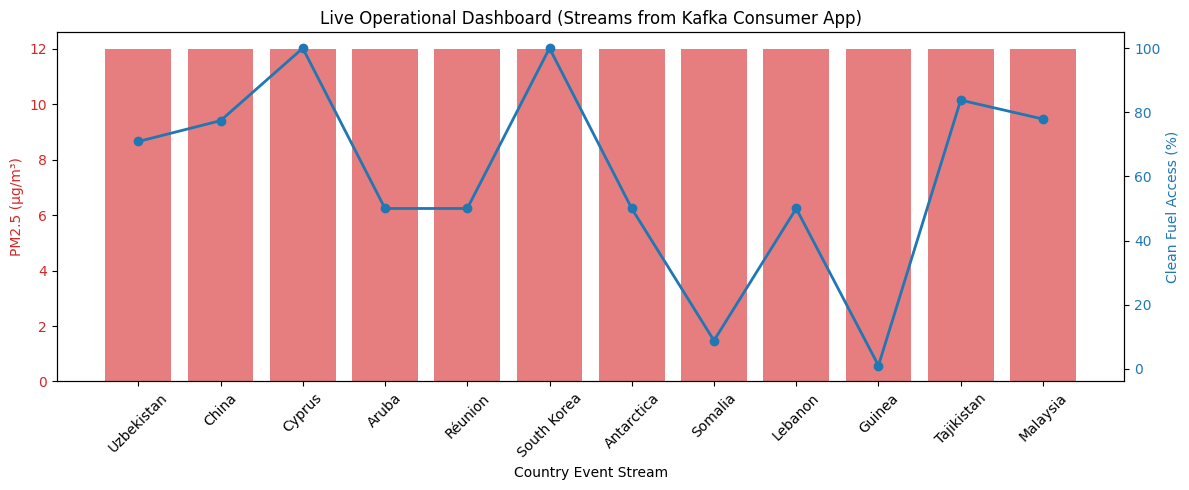

In [13]:
from confluent_kafka import Consumer
import json
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time

config_consumer = {
    'bootstrap.servers': 'localhost:9092',
    'group.id': 'realtime-group-dashboard',
    'auto.offset.reset': 'earliest'
}

try:
    consumer = Consumer(config_consumer)

    # Subscribe to topic
    consumer.subscribe(['air_quality_metrics'])

    print("Listening to real-time events streamed via Kafka topic 'air_quality_metrics'...")

    countries = []
    pm25_vals = []
    fuels = []

    while True:
        msg = consumer.poll(1.0)

        if msg is None:
            continue

        if msg.error():
            print(f"Consumer error: {msg.error()}")
            continue

        # Deserialize message manually
        val = json.loads(msg.value().decode('utf-8'))

        countries.append(val['country_name'])
        pm25_vals.append(val['pm25_value'])
        fuels.append(val['clean_fuel_access'])

        # Display rolling live dual-axis plot
        clear_output(wait=True)

        fig, ax1 = plt.subplots(figsize=(12, 5))

        color = 'tab:red'
        ax1.set_xlabel('Country Event Stream')
        ax1.set_ylabel('PM2.5 (µg/m³)', color=color)

        ax1.bar(
            countries[-12:],
            pm25_vals[-12:],
            color=color,
            alpha=0.6
        )

        ax1.tick_params(axis='y', labelcolor=color)
        plt.xticks(rotation=45)

        ax2 = ax1.twinx()

        color = 'tab:blue'
        ax2.set_ylabel('Clean Fuel Access (%)', color=color)

        ax2.plot(
            countries[-12:],
            fuels[-12:],
            color=color,
            marker='o',
            linewidth=2
        )

        ax2.tick_params(axis='y', labelcolor=color)

        plt.title("Live Operational Dashboard (Streams from Kafka Consumer App)")
        fig.tight_layout()

        display(fig)
        plt.close(fig)

        time.sleep(0.1)

except Exception as e:
    print(f"Kafka consumer connection or execution issue: {e}")

finally:
    consumer.close()